# 02  EDA & Insights

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../outputs/movies_cleaned.csv")

cols = detect_columns(df)

for key in ["rating", "popularity", "votes", "year"]:
    col = cols.get(key)
    if col:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Shape:", df.shape)
display(df.head())

Shape: (9837, 13)


,release_date,title,overview,popularity,vote_count,vote_average,original_language,genre,poster_url,working_url,release_year_derived,genre_count,decade
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940.0,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...,https://image.tmdb.org/t/p/original/1g0dhYtq4i...,2021.0,3,2020.0
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151.0,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...,https://image.tmdb.org/t/p/original/74xTEgt7R3...,2022.0,3,2020.0
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122.0,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...,https://image.tmdb.org/t/p/original/vDHsLnOWKl...,2022.0,1,2020.0
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076.0,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...,https://image.tmdb.org/t/p/original/4j0PNHkMr5...,2021.0,4,2020.0
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793.0,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...,https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...,2021.0,4,2020.0


In [13]:
df.info()
df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   release_date          9827 non-null   object 
 1   title                 9828 non-null   object 
 2   overview              9828 non-null   object 
 3   popularity            9827 non-null   float64
 4   vote_count            9826 non-null   float64
 5   vote_average          9826 non-null   float64
 6   original_language     9827 non-null   object 
 7   genre                 9826 non-null   object 
 8   poster_url            9826 non-null   object 
 9   working_url           9837 non-null   object 
 10  release_year_derived  9827 non-null   float64
 11  genre_count           9837 non-null   int64  
 12  decade                9827 non-null   float64
dtypes: float64(5), int64(1), object(7)
memory usage: 999.2+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
release_date,9827,5893,2022-03-10,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,9828,9514,Beauty and the Beast,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
overview,9828,9823,Dr. Raichi is one of the only survivors of the...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popularity,9827.0,NaN,NaN,NaN,40.320672,108.875673,7.1,16.1275,21.191,35.1745,5083.954
vote_count,9826.0,NaN,NaN,NaN,1392.943721,2611.303856,0.0,146.0,444.0,1376.0,31077.0
vote_average,9826.0,NaN,NaN,NaN,6.439467,1.129797,0.0,5.9,6.5,7.1,10.0
original_language,9827,44,en,7569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genre,9826,2337,Drama,466,NaN,NaN,NaN,NaN,NaN,NaN,NaN
poster_url,9826,9826,https://image.tmdb.org/t/p/original/1g0dhYtq4i...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
working_url,9837,9827,0,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Missing values

In [14]:
missing = (
    df.isna()
      .sum()
      .to_frame("missing")
      .assign(
          percent=lambda x: (x["missing"] / len(df) * 100).round(2)
      )
      .sort_values("percent", ascending=False)
)

display(missing)

,missing,percent
vote_count,11,0.11
vote_average,11,0.11
genre,11,0.11
poster_url,11,0.11
release_date,10,0.10
popularity,10,0.10
original_language,10,0.10
release_year_derived,10,0.10
decade,10,0.10
title,9,0.09


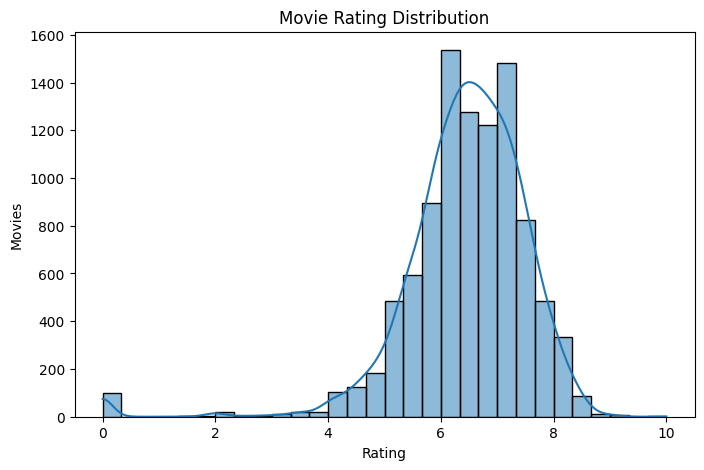

In [15]:
rating = cols.get("rating")

if rating:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[rating].dropna(), bins=30, kde=True)
    plt.title("Movie Rating Distribution")
    plt.xlabel("Rating")
    plt.ylabel("Movies")
    plt.show()

## Popularity distribution


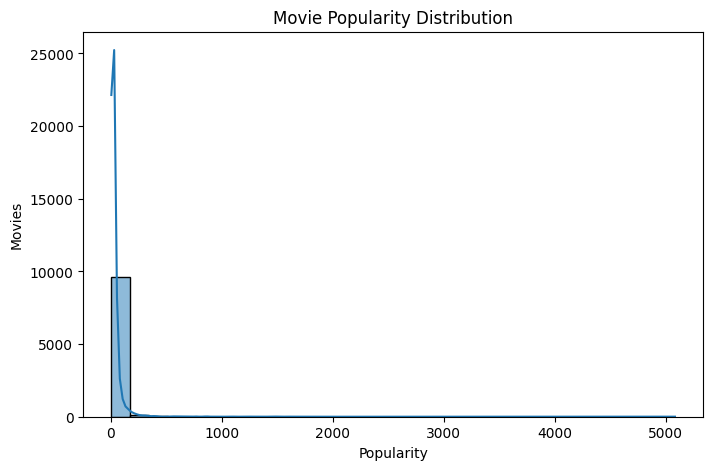

In [16]:
popularity = cols.get("popularity")

if popularity:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[popularity].dropna(), bins=30, kde=True)
    plt.title("Movie Popularity Distribution")
    plt.xlabel("Popularity")
    plt.ylabel("Movies")
    plt.show()

## Top 20 rated movies

In [17]:
title = cols.get("title")

if title and rating:
    top_rated = (
        df[[title, rating]]
        .dropna()
        .sort_values(rating, ascending=False)
        .head(20)
    )

    display(top_rated)

,title,vote_average
9401,Kung Fu Master Huo Yuanjia,10.0
7349,Franco Escamilla: Por La Anécdota,9.2
667,Demon Slayer: Kimetsu no Yaiba Sibling's Bond,9.1
2335,Impossible Things,9.1
7411,My Sex Doll,9.0
7024,Sex School: Dorms of Desire,9.0
6738,Mission «Sky»,9.0
2401,The Three Deaths of Marisela Escobedo,9.0
7049,Bring the Soul: The Movie,8.9
5079,"Ni tuyo, Ni mía",8.9


## Top 20 popular movies

In [18]:
if title and popularity:
    top_popular = (
        df[[title, popularity]]
        .dropna()
        .sort_values(popularity, ascending=False)
        .head(20)
    )

    display(top_popular)

,title,popularity
0,Spider-Man: No Way Home,5083.954
1,The Batman,3827.658
2,No Exit,2618.087
3,Encanto,2402.201
4,The King's Man,1895.511
5,The Commando,1750.484
6,Scream,1675.161
7,Kimi,1601.782
8,Fistful of Vengeance,1594.013
9,Eternals,1537.406


## Rating by year

In [19]:
year = cols.get("year")

if year and rating:
    yearly = (
        df.dropna(subset=[year, rating])
          .groupby(year)[rating]
          .mean()
          .reset_index()
    )

    plt.figure(figsize=(12, 5))
    sns.lineplot(data=yearly, x=year, y=rating)
    plt.title("Average Movie Rating by Year")
    plt.xlabel("Year")
    plt.ylabel("Average Rating")
    plt.show()

## Rating vs Popularity



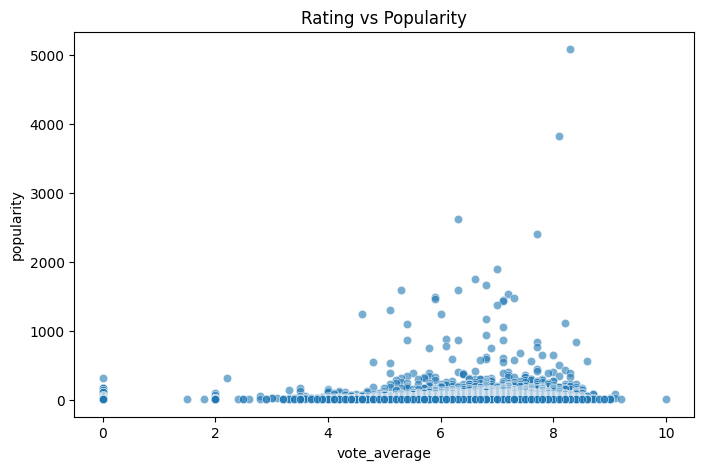

In [21]:
if rating and popularity:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=df,
        x=rating,
        y=popularity,
        alpha=.6
    )
    plt.title("Rating vs Popularity")
    plt.show()

##  Correlation



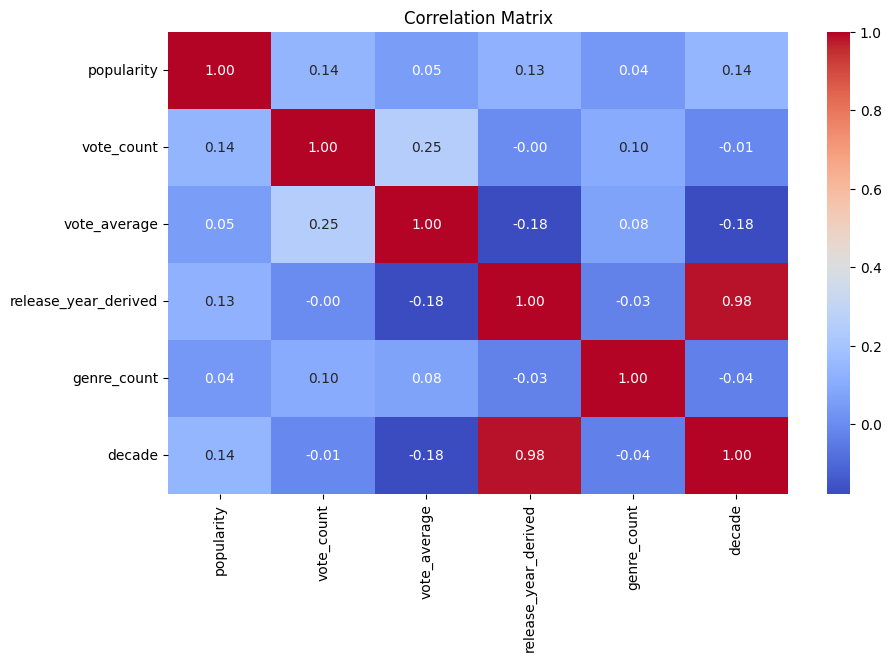

In [23]:
num_cols = df.select_dtypes(include="number")

plt.figure(figsize=(10, 6))
sns.heatmap(
    num_cols.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

In [24]:
genre = cols.get("genre")

if genre:
    genres = (
        df[genre]
        .dropna()
        .astype(str)
        .str.split(r"[,|;/]+")
        .explode()
        .str.strip()
    )

    genre_count = (
        genres[genres != ""]
        .value_counts()
        .head(15)
    )

    display(genre_count)

genre
Drama              3744
Comedy             3031
Action             2686
Thriller           2488
Adventure          1853
Romance            1476
Horror             1470
Animation          1438
Family             1414
Fantasy            1308
Science Fiction    1273
Crime              1242
Mystery             773
History             427
War                 308
Name: count, dtype: int64

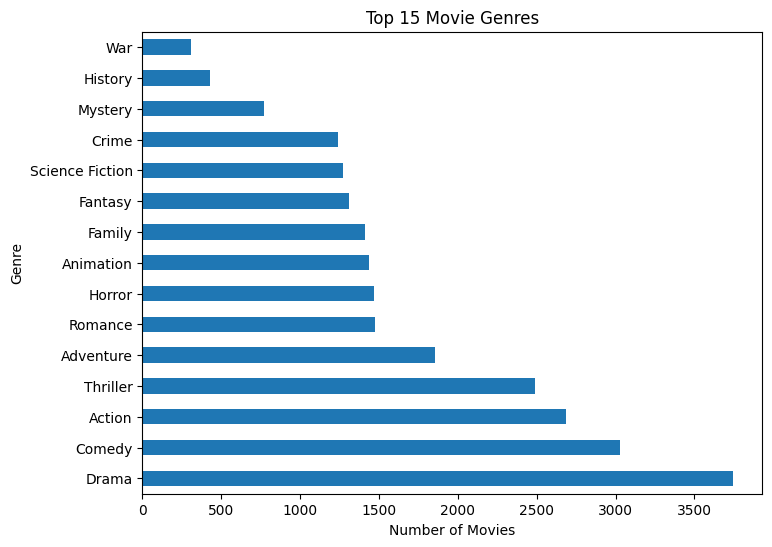

In [25]:
if genre:
    genre_count.plot(
        kind="barh",
        figsize=(8, 6),
        title="Top 15 Movie Genres"
    )

    plt.xlabel("Number of Movies")
    plt.ylabel("Genre")
    plt.show()

In [26]:
if genre and rating:
    temp = df[[genre, rating]].dropna().copy()

    temp[genre] = (
        temp[genre]
        .astype(str)
        .str.split(r"[,|;/]+")
    )

    temp = temp.explode(genre)
    temp[genre] = temp[genre].str.strip()

    genre_rating = (
        temp[temp[genre] != ""]
        .groupby(genre)[rating]
        .agg(["mean", "count"])
        .query("count >= 10")
        .sort_values("mean", ascending=False)
        .head(15)
    )

    display(genre_rating)

,mean,count
genre,,
History,6.965574,427
War,6.948701,308
Music,6.879322,295
Animation,6.846384,1438
Western,6.754745,137
Drama,6.706143,3744
Documentary,6.663721,215
Family,6.581047,1414
Romance,6.560772,1476


In [27]:
# 13


if "decade" in df.columns and rating:
    decade_rating = (
        df.dropna(subset=["decade", rating])
          .groupby("decade")[rating]
          .mean()
          .reset_index()
    )

    display(decade_rating)

,decade,vote_average
0,1900.0,8.000000
1,1920.0,7.818182
2,1930.0,7.375758
3,1940.0,7.342000
4,1950.0,7.404950
5,1960.0,7.190732
6,1970.0,6.781784
7,1980.0,6.554200
8,1990.0,6.513429
9,2000.0,6.392403


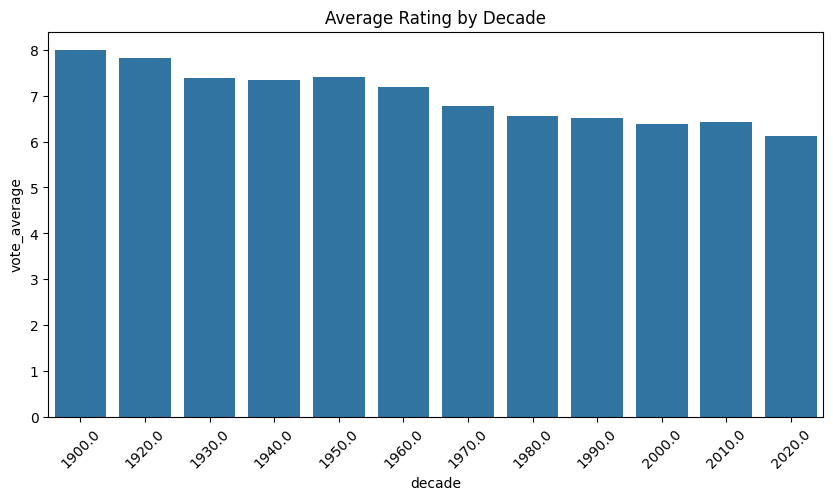

In [28]:
if "decade" in df.columns:
    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=decade_rating,
        x="decade",
        y=rating
    )
    plt.title("Average Rating by Decade")
    plt.xticks(rotation=45)
    plt.show()

In [29]:
# 14

print("===== MOVIE DATASET INSIGHTS =====")

if rating:
    print(f"Average rating: {df[rating].mean():.2f}")
    print(f"Highest rating: {df[rating].max():.2f}")

if popularity:
    print(f"Average popularity: {df[popularity].mean():.2f}")
    print(f"Highest popularity: {df[popularity].max():.2f}")

if year:
    print(f"Oldest year: {df[year].min():.0f}")
    print(f"Latest year: {df[year].max():.0f}")

print(f"Total movies: {len(df):,}")

===== MOVIE DATASET INSIGHTS =====
Average rating: 6.44
Highest rating: 10.00
Average popularity: 40.32
Highest popularity: 5083.95
Total movies: 9,837
